# Extratropical Modes of Variability — Raw EOF Analysis

Computes EOF patterns, PCs, teleconnection slopes, and variance fractions directly from
model / obs raw fields, using `util.mov_analyzer.ModeAnalyzer` and `util/config.json`.

**Notebook structure:**
1. Imports
2. Shared configuration (period, mode, season, model list)
3. Run analysis (obs + all models)

> For plotting pre-computed PMP diagnostic outputs, see [`plot_mov_pattern.ipynb`](plot_mov_pattern.ipynb).

In [54]:
%load_ext autoreload
%autoreload 2

import os
import string 
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.colors as mcolors
from cartopy.util import add_cyclic_point
import matplotlib.ticker as mticker

from util.mov_analyzer import ModeAnalyzer
from util.mov_plotter import add_sig_dots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Shared Configuration

Edit the settings below, then run this cell and the analysis cell.

In [28]:
# ── User settings ────────────────────────────────────────────────────────────
mode   = "NAO"   # any key in util/config.json → modes
season = "DJF"   # MONTHLY | ANNUAL | DJF | MAM | JJA | SON | None (use config default)
period = (1985, 2014)

model_list = ["LR", "NARRM", "NARRM_r0125", "EARRM", "AMZRRM"]  # keys in config → datasets

custom_obs_path = None   # set to a file path to override the config default
custom_obs_name = None   # optional label when using custom_obs_path

# Significance levels used during plotting (choose one or both at plot time).
# The raw p-value map (slope_pval / slope_pval_proj) is saved in the NetCDF,
# so you can apply any threshold later without re-running the analysis.
SIG_LEVELS = [0.05, 0.10]

# Set OVERWRITE = True to force recomputation even if cached files already exist.
# Useful after changing analysis code or fixing bugs. Reset to False when done.
OVERWRITE = False

# Shared output directory for all cached NetCDF results.
# Files are named {mode}_{season}_{y0}-{y1}_{obs_name}_{case_name}.nc
# so files for different modes / seasons / periods / obs never overwrite each other.
OUT_DIR = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper/figure_data/mov_analysis/"
FIG_DIR = "./figs/"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
# ─────────────────────────────────────────────────────────────────────────────

analyzer = ModeAnalyzer("./util/config.json")

## Run Analysis

For each obs / model, checks whether a cached NetCDF already exists in `OUT_DIR`:
- **Found** → loads it directly (fast path); if proj variables are missing they are recomputed and the file is updated
- **Not found** → runs the full EOF pipeline, saves to `OUT_DIR`, then continues

### Variables saved per dataset

| Variable | Description |
|---|---|
| `eof` | Independent EOF spatial pattern |
| `pc` | Standardized PC (independent EOF) |
| `frac` | Explained variance fraction |
| `slope` | Regression of full field onto `pc` |
| `slope_pval` | Two-tailed p-value of `slope` (t-test, df = n−2) |
| `corr` | Pearson r with `pc` |
| `pc_proj` | Standardized PC from projection onto **obs EOF** (common base) |
| `slope_proj` | Regression of full field onto `pc_proj` |
| `slope_pval_proj` | Two-tailed p-value of `slope_proj` |
| `corr_proj` | Pearson r with `pc_proj` |

Both `slope_pval` and `slope_pval_proj` store **raw continuous p-values** (0–1).
Apply any threshold at plot time: `ds["slope_pval"] < 0.05`, `< 0.10`, etc.

In [20]:
print(f"Mode: {mode} | Season: {season} | Period: {period[0]}-{period[1]}")
print(f"Output dir: {OUT_DIR}")
print(f"Expected filenames: {mode}_{season}_{period[0]}-{period[1]}_<obs>_<case>.nc")
print(f"Overwrite: {OVERWRITE}\n")

obs_ds, model_results = analyzer.analyze_or_load_all(
    mode_name=mode,
    model_list=model_list,
    out_dir=OUT_DIR,
    custom_obs_path=custom_obs_path,
    custom_obs_name=custom_obs_name,
    period=period,
    season=season,
    overwrite=OVERWRITE,
)

# ── Summary ───────────────────────────────────────────────────────────────────
def _sig_pct(ds, key, level):
    if key not in ds:
        return "  n/a  "
    return f"{(ds[key].values < level).mean() * 100:5.1f}%"

hdr_parts = ["frac"]
for lv in SIG_LEVELS:
    hdr_parts += [f"indep p<{lv:.2f}", f"proj p<{lv:.2f}"]
print(f"  {'name':20s}  " + "  ".join(f"{h:>12}" for h in hdr_parts))
print(f"  {'-'*20}  " + "  ".join(["-"*12] * len(hdr_parts)))

all_cases = [("obs", obs_ds)] + list(model_results.items())
for name, ds in all_cases:
    row = [f"{float(ds['frac']):.3f}      "]
    for lv in SIG_LEVELS:
        row += [_sig_pct(ds, "slope_pval", lv), _sig_pct(ds, "slope_pval_proj", lv)]
    print(f"  {name:20s}  " + "  ".join(f"{v:>12}" for v in row))

Mode: NAO | Season: DJF | Period: 1985-2014
Output dir: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper/figure_data/mov_analysis/
Expected filenames: NAO_DJF_1985-2014_<obs>_<case>.nc
Overwrite: False

  Loading obs from cache: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper/figure_data/mov_analysis/NAO_DJF_1985-2014_NOAA-20C_NOAA-20C.nc
  Loading LR from cache: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper/figure_data/mov_analysis/NAO_DJF_1985-2014_NOAA-20C_LR.nc
  Loading NARRM from cache: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper/figure_data/mov_analysis/NAO_DJF_1985-2014_NOAA-20C_NARRM.nc
  Loading NARRM_r0125 from cache: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper/figure_data/mov_analysis/NAO_DJF_1985-2014_NOAA-20C_NARRM_r0125.nc
  Loading EARRM from cache: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_rrm_paper/figure_data/mov_analysis/NAO_DJF_1985-2014_NOAA-20C_EARRM.n

## Plot Settings (shared)

Adjust these before running either plot cell below.

In [29]:
# ── Shared plot settings ──────────────────────────────────────────────────────
PLOT_VAR    = "slope_proj"  # "slope" (independent EOF) or "slope_proj" (common base)
SIG_LEVEL   = 0.05          # significance threshold for stippling (0.05 or 0.10)
CMAP        = "RdBu_r"
DOT_DENSITY = 2             # stride for stippling dots (larger = sparser)

PVAL_VAR = PLOT_VAR.replace("slope", "slope_pval")   # auto-match pval key

def _get_var(ds, var, fallback):
    """Return ds[var] if present, otherwise ds[fallback]."""
    return ds[var] if var in ds else ds[fallback]

# Mode region bounds from config
mode_info = analyzer.cfg.get_mode_info(mode)
lat_bnds  = mode_info.get("lat_bnds")   # e.g. [20, 80]
lon_bnds  = mode_info.get("lon_bnds")   # e.g. [-80, 40]

# Unit conversion: psl raw data is in Pa → display in hPa
field_var = mode_info.get("var", "")
if field_var == "psl":
    unit_scale = 1e-2
    unit_label = "hPa"
else:
    unit_scale = 1.0
    unit_label = ""

all_cases = [("obs", obs_ds)] + list(model_results.items())
ncols = len(all_cases)

# Pre-compute shared color limits from obs (nanmax handles NaN outside mode domain)
eof_vmax = float(np.nanmax(np.abs(obs_ds["eof"].values)) * 0.8) * unit_scale
reg_vmax = float(np.nanmax(np.abs(_get_var(obs_ds, PLOT_VAR, "slope").values)) * 0.8) * unit_scale

print(f"Settings: PLOT_VAR={PLOT_VAR}, SIG_LEVEL={SIG_LEVEL}, unit={unit_label or 'native'}")
print(f"Color limits: eof_vmax={eof_vmax:.4f}, reg_vmax={reg_vmax:.4f}")

Settings: PLOT_VAR=slope_proj, SIG_LEVEL=0.05, unit=hPa
Color limits: eof_vmax=0.0003, reg_vmax=4.8264


### Figure 1 — Regional EOF Pattern (mode domain)

Saved → ./figs/NAO_DJF_eof_pattern_NAO_region_3x2.pdf


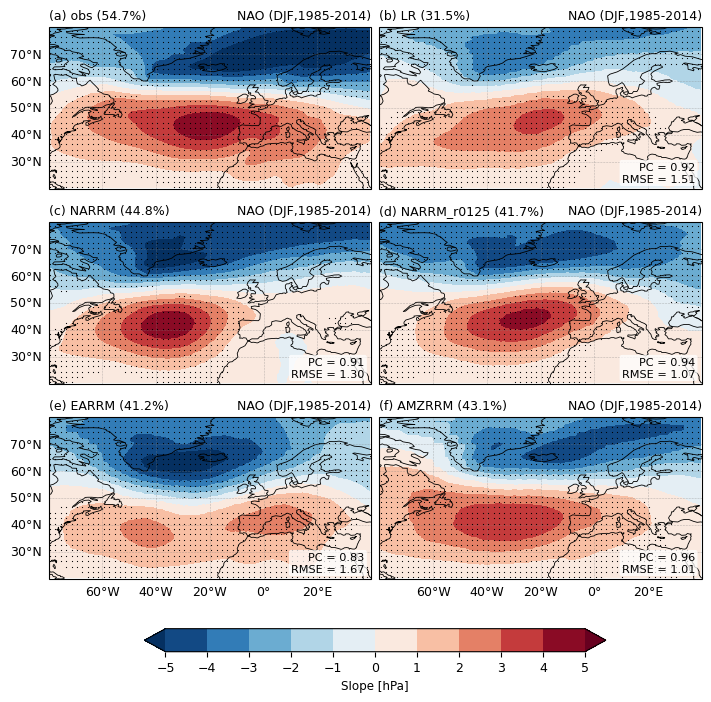

In [78]:
def wrap_lon_180(da, lon_name="lon"):
    """Convert longitude from [0, 360) to [-180, 180) and sort."""
    lon = da[lon_name]
    if float(lon.max()) > 180:
        da = da.assign_coords({lon_name: ((lon + 180) % 360) - 180})
        da = da.sortby(lon_name)
    return da

def add_sig_dots(ax, pval, sig_level=0.05, dot_density=2, dot_size=3):
    """
    Add significance dots where p-value < sig_level.
    """
    lon = pval.lon.values
    lat = pval.lat.values

    lon2d, lat2d = np.meshgrid(lon, lat)
    sig_mask = np.isfinite(pval.values) & (pval.values < sig_level)

    lon_plot = lon2d[::dot_density, ::dot_density]
    lat_plot = lat2d[::dot_density, ::dot_density]
    mask_plot = sig_mask[::dot_density, ::dot_density]

    ax.scatter(
        lon_plot[mask_plot],
        lat_plot[mask_plot],
        s=dot_size,
        color="k",
        marker=".",
        linewidths=0,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

def calc_pattern_corr_rmse(ref, test):
    """
    Compute pattern correlation and RMSE between two 2D arrays,
    using only points valid in both fields.
    """
    mask = np.isfinite(ref) & np.isfinite(test)
    if mask.sum() == 0:
        return np.nan, np.nan

    ref1 = ref[mask]
    test1 = test[mask]

    ref_anom = ref1 - ref1.mean()
    test_anom = test1 - test1.mean()

    denom = np.sqrt(np.sum(ref_anom**2) * np.sum(test_anom**2))
    if denom == 0:
        pcorr = np.nan
    else:
        pcorr = np.sum(ref_anom * test_anom) / denom

    rmse = np.sqrt(np.mean((test1 - ref1)**2))
    return pcorr, rmse

fontz = 9
plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": fontz * 0.95,
    "axes.labelsize": fontz * 0.95,
    "xtick.labelsize": fontz * 0.9,
    "ytick.labelsize": fontz * 0.9,
})

# --------------------------------------------------
# Figure settings
# --------------------------------------------------
figsize = (7, 7)
nrows, ncols_plot = 3, 2
constrained_layout = True
projection = ccrs.PlateCarree()
dpi = 300
bbox_inches = "tight"
figname = f"{mode}_{season}_eof_pattern_NAO_region_3x2.pdf"
rstring = f"{mode} ({season},{period[0]}-{period[1]})"

SIG_LEVEL = 0.05
DOT_DENSITY = 2
DOT_SIZE = 3

fig1, axes1 = plt.subplots(
    nrows,
    ncols_plot,
    figsize=figsize,
    subplot_kw={"projection": projection},
    constrained_layout=constrained_layout,
)

axes1 = axes1.flatten()

levels = np.linspace(-5, 5, 11)
panel_labels = list(string.ascii_lowercase)

# --------------------------------------------------
# First pass: prepare plotted fields
# --------------------------------------------------
plot_data_list = []
pval_list = []
frac_list = []
name_list = []

for i in range(len(all_cases)):
    name, ds = all_cases[i]

    eof = wrap_lon_180(ds["eof"])
    slope = wrap_lon_180(ds["slope"] * unit_scale)
    pval = wrap_lon_180(ds["slope_pval"])

    if not (
        np.array_equal(slope.lon.values, eof.lon.values) and
        np.array_equal(slope.lat.values, eof.lat.values)
    ):
        slope = slope.interp(lon=eof.lon, lat=eof.lat)

    if not (
        np.array_equal(pval.lon.values, eof.lon.values) and
        np.array_equal(pval.lat.values, eof.lat.values)
    ):
        pval = pval.interp(lon=eof.lon, lat=eof.lat)

    valid_mask = np.isfinite(eof)

    plot_data = slope.where(valid_mask)
    pval = pval.where(valid_mask)

    plot_data_list.append(plot_data)
    pval_list.append(pval)
    frac_list.append(float(ds["frac"]) * 100 if "frac" in ds else None)
    name_list.append(name)

# panel (a) as reference
ref_data = plot_data_list[0].values

im = None

for i, ax in enumerate(axes1):

    if i >= len(all_cases):
        ax.set_visible(False)
        continue

    plot_data = plot_data_list[i]
    pval = pval_list[i]
    name = name_list[i]
    frac = frac_list[i]

    lon = plot_data.lon.values
    lat = plot_data.lat.values
    data = plot_data.values

    im = ax.contourf(
        lon,
        lat,
        data,
        levels=levels,
        cmap=CMAP,
        transform=ccrs.PlateCarree(),
        extend="both",
    )

    add_sig_dots(
        ax,
        pval,
        sig_level=SIG_LEVEL,
        dot_density=DOT_DENSITY,
        dot_size=DOT_SIZE,
    )

    ax.coastlines(linewidth=0.6)

    if lat_bnds and lon_bnds:
        ax.set_extent(
            [lon_bnds[0], lon_bnds[1], lat_bnds[0], lat_bnds[1]],
            crs=ccrs.PlateCarree(),
        )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False

    if i % ncols_plot != 0:
        gl.left_labels = False

    if i < (nrows - 1) * ncols_plot:
        gl.bottom_labels = False

    gl.xlabel_style = {"size": fontz}
    gl.ylabel_style = {"size": fontz}

    frac_str = f" ({frac:.1f}%)" if frac is not None else ""

    ax.set_title(
        f"({panel_labels[i]}) {name}{frac_str}",
        fontsize=fontz,
        loc="left",
        pad=6,
    )
    ax.set_title(
        f"{rstring}",
        fontsize=fontz,
        loc="right",
        pad=6,
    )

    # --------------------------------------------------
    # Pattern correlation and RMSE textbox
    # --------------------------------------------------
    if i != 0:
        pcorr, rmse = calc_pattern_corr_rmse(ref_data, data)
    
        text_str = (
            f"PC = {pcorr:.2f}\n"
            f"RMSE = {rmse:.2f}"
        )
    
        ax.text(
            0.98, 0.03,
            text_str,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=fontz * 0.9,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
            ),
            zorder=4,
        )
        
# --------------------------------------------------
# Shared colorbar
# --------------------------------------------------
cb_label = f"Slope [{unit_label}]" if unit_label else "Slope"

cbar = fig1.colorbar(
    im,
    ax=axes1,
    orientation="horizontal",
    fraction=0.04,
    pad=0.05,
    ticks=levels,
)

cbar.set_label(cb_label)
cbar.ax.tick_params(labelsize=fontz)

fig1_path = os.path.join(FIG_DIR, figname)
fig1.savefig(
    fig1_path,
    dpi=dpi,
    bbox_inches=bbox_inches,
)

print(f"Saved → {fig1_path}")
plt.show()

### Figure 2 — Global Regression Map with Significance Stippling

Saved → ./figs/NAO_DJF_slope_proj_global_sig0.05.pdf


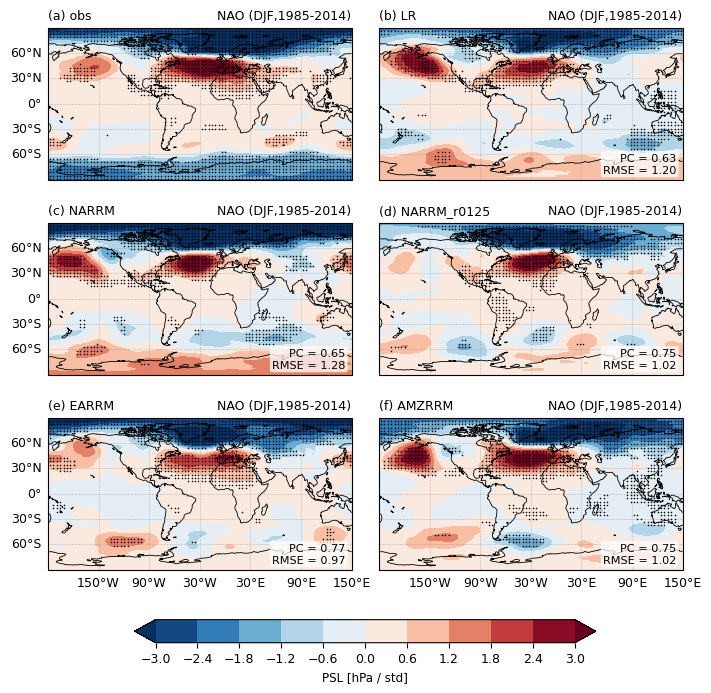

In [82]:
def add_sig_dots(ax, pval, sig_level=0.05, dot_density=2, dot_size=3):
    """
    Add significance dots where p-value < sig_level.
    """
    lon = pval.lon.values
    lat = pval.lat.values

    lon2d, lat2d = np.meshgrid(lon, lat)
    sig_mask = np.isfinite(pval.values) & (pval.values < sig_level)

    lon_plot = lon2d[::dot_density, ::dot_density]
    lat_plot = lat2d[::dot_density, ::dot_density]
    mask_plot = sig_mask[::dot_density, ::dot_density]

    ax.scatter(
        lon_plot[mask_plot],
        lat_plot[mask_plot],
        s=dot_size,
        color="k",
        marker=".",
        linewidths=0,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

def calc_pattern_corr_rmse(ref, test):
    """
    Compute pattern correlation and RMSE between two 2D arrays
    using only valid points.
    """
    mask = np.isfinite(ref) & np.isfinite(test)
    if mask.sum() == 0:
        return np.nan, np.nan

    ref1 = ref[mask]
    test1 = test[mask]

    ref_anom = ref1 - ref1.mean()
    test_anom = test1 - test1.mean()

    denom = np.sqrt(np.sum(ref_anom**2) * np.sum(test_anom**2))
    pcorr = np.nan if denom == 0 else np.sum(ref_anom * test_anom) / denom
    rmse = np.sqrt(np.mean((test1 - ref1)**2))

    return pcorr, rmse

fontz = 9
plt.rcParams.update({
    "font.size": fontz,
    "axes.titlesize": fontz * 0.95,
    "axes.labelsize": fontz * 0.95,
    "xtick.labelsize": fontz * 0.9,
    "ytick.labelsize": fontz * 0.9,
})

# --------------------------------------------------
# Global regression figure settings
# --------------------------------------------------

figsize = (7, 7)
nrows, ncols_plot = 3, 2
constrained_layout = True

# NAO-focused projection: keep PlateCarree for readable labels,
# but center over the North Atlantic
projection = ccrs.PlateCarree(central_longitude=-30)

dpi = 300
bbox_inches = "tight"

figname = f"{mode}_{season}_{PLOT_VAR}_global_sig{SIG_LEVEL}.pdf"
rstring = f"{mode} ({season},{period[0]}-{period[1]})"
reg_cb_label = "PSL [hPa / std]"

DOT_SIZE = 5
DOT_DENSITY = 4
levels = np.linspace(-3.0, 3.0, 11)

panel_labels = list(string.ascii_lowercase)

fig2, axes2 = plt.subplots(
    nrows,
    ncols_plot,
    figsize=figsize,
    subplot_kw={"projection": projection},
    constrained_layout=constrained_layout,
)

axes2 = axes2.flatten()

# --------------------------------------------------
# First pass: prepare data
# --------------------------------------------------

field_list = []
pval_list = []
name_list = []

for i in range(len(all_cases)):
    name, ds = all_cases[i]

    field = _get_var(ds, PLOT_VAR, "slope") * unit_scale
    pval = _get_var(ds, PVAL_VAR, "slope_pval")

    if not (
        np.array_equal(field.lon.values, pval.lon.values)
        and
        np.array_equal(field.lat.values, pval.lat.values)
    ):
        pval = pval.interp(
            lon=field.lon,
            lat=field.lat
        )

    field_list.append(field)
    pval_list.append(pval)
    name_list.append(name)

# observation = panel (a)
ref_field = field_list[0]
ref_data_cyc, ref_lon_cyc = add_cyclic_point(
    ref_field.values,
    coord=ref_field.lon.values
)
ref_data = ref_data_cyc

im = None

for i, ax in enumerate(axes2):

    if i >= len(all_cases):
        ax.set_visible(False)
        continue

    field = field_list[i]
    pval = pval_list[i]
    name = name_list[i]

    lon = field.lon.values
    lat = field.lat.values

    # add cyclic point to avoid seam in global map
    data_cyc, lon_cyc = add_cyclic_point(
        field.values,
        coord=lon
    )

    pval_cyc, _ = add_cyclic_point(
        pval.values,
        coord=lon
    )

    im = ax.contourf(
        lon_cyc,
        lat,
        data_cyc,
        levels=levels,
        cmap=CMAP,
        transform=ccrs.PlateCarree(),
        extend="both",
    )

    ax.coastlines(linewidth=0.6)
    ax.set_global()

    # ---------------------------------
    # significance dots
    # ---------------------------------

    pval_plot = xr.DataArray(
        pval_cyc,
        coords={"lat": lat, "lon": lon_cyc},
        dims=("lat", "lon"),
    )

    add_sig_dots(
        ax,
        pval_plot,
        sig_level=SIG_LEVEL,
        dot_density=DOT_DENSITY,
        dot_size=DOT_SIZE,
    )

    # ---------------------------------
    # latitude / longitude labels
    # ---------------------------------

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.4,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )

    gl.top_labels = False
    gl.right_labels = False

    # only left column shows latitude labels
    if i % ncols_plot != 0:
        gl.left_labels = False

    # only bottom row shows longitude labels
    if i < (nrows - 1) * ncols_plot:
        gl.bottom_labels = False

    gl.xlocator = mticker.FixedLocator(
        [-150, -90, -30, 30, 90, 150]
    )
    gl.ylocator = mticker.FixedLocator(
        [-60, -30, 0, 30, 60]
    )

    gl.xlabel_style = {"size": fontz}
    gl.ylabel_style = {"size": fontz}

    # ---------------------------------
    # titles
    # ---------------------------------

    ax.set_title(
        f"({panel_labels[i]}) {name}",
        fontsize=fontz,
        loc="left",
        pad=6,
    )

    ax.set_title(
        f"{rstring}",
        fontsize=fontz,
        loc="right",
        pad=6,
    )

    # ---------------------------------
    # PC + RMSE textbox
    # skip observation panel
    # ---------------------------------

    if i != 0:
        pcorr, rmse = calc_pattern_corr_rmse(
            ref_data,
            data_cyc
        )

        text_str = (
            f"PC = {pcorr:.2f}\n"
            f"RMSE = {rmse:.2f}"
        )

        ax.text(
            0.98,
            0.03,
            text_str,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=fontz * 0.9,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.75,
            ),
            zorder=4,
        )

# --------------------------------------------------
# Shared colorbar
# --------------------------------------------------

cbar = fig2.colorbar(
    im,
    ax=axes2,
    orientation="horizontal",
    fraction=0.04,
    pad=0.05,
    ticks=levels,
)

cbar.set_label(reg_cb_label)
cbar.ax.tick_params(labelsize=fontz)

fig2_path = os.path.join(
    FIG_DIR,
    figname
)

fig2.savefig(
    fig2_path,
    dpi=dpi,
    bbox_inches=bbox_inches,
)

print(f"Saved → {fig2_path}")
plt.show()

## Plot: PC Time Series Comparison

Plots the standardized PC time series for obs and all models on one panel.

- `PC_VAR = "pc"` → independent EOF basis (each dataset's own EOF)
- `PC_VAR = "pc_proj"` → common-base (projected onto obs EOF) — better for direct comparison

In [80]:
def standardize_pc(pc):
    vals = np.asarray(pc.values, dtype=float)
    mask = np.isfinite(vals)

    out = np.full_like(vals, np.nan, dtype=float)
    if mask.sum() == 0:
        return out

    mean = vals[mask].mean()
    std = vals[mask].std()

    if std == 0:
        return out

    out[mask] = (vals[mask] - mean) / std
    return out


def get_time_coord(da):
    if "time" in da.coords:
        return da.time.values
    return np.arange(da.size)


def calc_timeseries_corr(ref, test):
    ref = np.asarray(ref)
    test = np.asarray(test)

    mask = np.isfinite(ref) & np.isfinite(test)
    if mask.sum() == 0:
        return np.nan

    ref1 = ref[mask]
    test1 = test[mask]

    if ref1.std() == 0 or test1.std() == 0:
        return np.nan

    return np.corrcoef(ref1, test1)[0, 1]


def plot_standardized_pc_timeseries(
    all_cases,
    FIG_DIR,
    mode,
    season,
    period,
    PC_VAR="pc_proj",
    fontz=10,
    figsize=(9, 4),
    dpi=300,
    bbox_inches="tight",
    linewidth_obs=2.2,
    linewidth_model=1.3,
    alpha_model=0.9,
    title=None,
):
    """
    Plot standardized PC time series for obs + all models.

    Rules:
    - If PC_VAR == "pc": everyone uses "pc"
    - If PC_VAR == "pc_proj":
        * OBS uses "pc" as the reference series
        * models use "pc_proj"
    """

    plt.rcParams.update({
        "font.size": fontz,
        "axes.titlesize": fontz * 0.95,
        "axes.labelsize": fontz * 0.95,
        "xtick.labelsize": fontz * 0.9,
        "ytick.labelsize": fontz * 0.9,
        "legend.fontsize": fontz * 0.82,
    })

    if title is None:
        if PC_VAR == "pc_proj":
            title = (
                f"{mode} ({season}, {period[0]}-{period[1]}) | "
                f"Standardized PC (projected onto OBS EOF)"
            )
        else:
            title = (
                f"{mode} ({season}, {period[0]}-{period[1]}) | "
                f"Standardized PC (independent EOF basis)"
            )

    figname = f"{mode}_{season}_{PC_VAR}_standardized_timeseries.pdf"

    fig, ax = plt.subplots(
        figsize=figsize,
        constrained_layout=True,
    )

    # OBS reference
    obs_name, obs_ds = all_cases[0]

    if "pc" not in obs_ds:
        raise ValueError("pc not found in observation dataset.")

    obs_var = "pc"
    obs_pc = obs_ds[obs_var].squeeze()
    time = get_time_coord(obs_pc)
    obs_std = standardize_pc(obs_pc)

    obs_label = f"{obs_name} (reference: {obs_var})"
    ax.plot(
        time,
        obs_std,
        color="k",
        linewidth=linewidth_obs,
        label=obs_label,
        zorder=5,
    )

    # Models
    for name, ds in all_cases[1:]:
        model_var = PC_VAR

        if model_var not in ds:
            print(f"Warning: {model_var} not found in {name}; skipping.")
            continue

        pc = ds[model_var].squeeze()
        pc_std = standardize_pc(pc)

        corr = calc_timeseries_corr(obs_std, pc_std)
        label = f"{name} (r={corr:.2f})"

        ax.plot(
            time,
            pc_std,
            linewidth=linewidth_model,
            alpha=alpha_model,
            label=label,
            zorder=2,
        )

    ax.axhline(
        0,
        color="k",
        linewidth=0.8,
        linestyle="--",
        alpha=0.8,
    )

    ax.set_title(title)
    ax.set_ylabel("Standardized PC")
    ax.set_xlabel("Time")

    ax.legend(
        loc="upper right",
        frameon=False,
        ncol=1,
    )

    ax.grid(True, linestyle="--", alpha=0.3)

    fig_path = os.path.join(FIG_DIR, figname)
    fig.savefig(
        fig_path,
        dpi=dpi,
        bbox_inches=bbox_inches,
    )

    print(f"Saved → {fig_path}")
    plt.show()

Saved → ./figs/NAO_DJF_pc_proj_standardized_timeseries.pdf


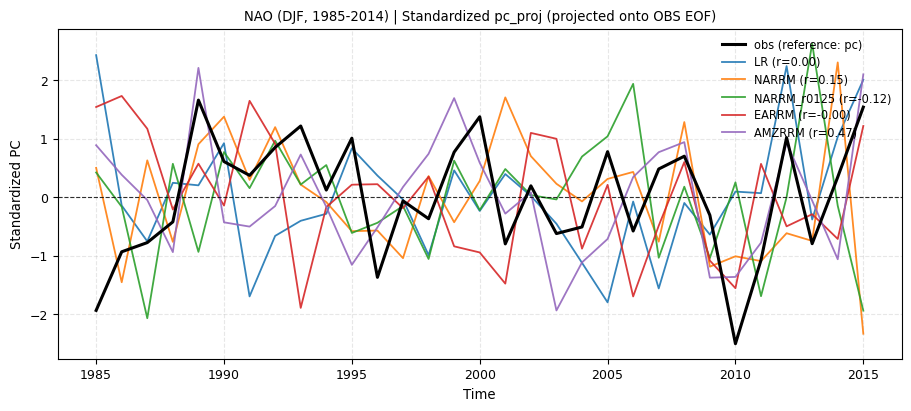

In [81]:
PC_VAR = "pc_proj"

pc_desc = {
    "pc": "independent EOF basis",
    "pc_proj": "projected onto OBS EOF",
}[PC_VAR]

plot_standardized_pc_timeseries(
    all_cases=all_cases,
    FIG_DIR=FIG_DIR,
    mode=mode,
    season=season,
    period=period,
    PC_VAR=PC_VAR,
    fontz=10,
    figsize=(9, 4),
    title=(
        f"{mode} ({season}, {period[0]}-{period[1]}) | "
        f"Standardized {PC_VAR} ({pc_desc})"
    ),
)